# 2. Tiền xử lý dữ liệu

**Input:** `exps/data/data_EDA.csv`  
**Output:** `exps/feature4/` gồm `x_train.csv, y_train.csv, x_test.csv, test_id.csv, info.json`

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "TV4"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "pre-processing4"
FEATURE_SET = "feature4"   # thư mục output trong exps/
seed_everything()

## VIỆC CỦA TV4 — tạo `feature4` (feature engineering), làm song song với TV1
Làm trên phần làm sạch **baseline** (không chờ TV1). Khi ghép (giai đoạn 2) sẽ chép các hàm FE sang notebook của TV1.
1. Viết thêm nhóm đặc trưng ở mục 2.3: `baths` (tổng phòng tắm), `age` (YrSold − YearBuilt, YrSold − YearRemodAdd), `flags` (HasPool, HasGarage, HasBsmt, Has2ndFloor...), `interactions` (OverallQual × GrLivArea...). Tự đề xuất ít nhất 1 nhóm.
2. **Ablation:** bật từng nhóm (`USE = [...]`), lưu thành `feature4_1`, `feature4_2`... hoặc chạy lần lượt rồi đo bằng traditional model → bảng cho báo cáo Chương 5.
3. Thử giảm skew: log1p các cột số có |skew| > 0.75 (tính skew **chỉ trên dòng train**).

In [4]:
df, numeric_columns, category_columns = load_eda()
df.shape

(2919, 82)

## 2.1. Làm sạch
**Baseline = cách của code tham khảo:** bỏ 4 cột thiếu nhiều, cột phân loại điền mode. Cột số để NaN — `make_pipeline()` ở stage 4 sẽ điền median **trong từng fold**.

In [5]:
DROP_COLS = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
df = df.drop(columns=DROP_COLS)
cat_cols = [c for c in category_columns if c not in DROP_COLS] + ['MSSubClass']
df['MSSubClass'] = df['MSSubClass'].astype(str)    # mã loại nhà, không phải số
for c in cat_cols:
    df[c] = df[c].fillna(df.loc[df.is_train == 1, c].mode()[0])   # mode tính trên train
df[cat_cols].isna().sum().sum()

np.int64(0)

## 2.2. Ngoại lai

In [6]:
outlier_mask = (df.is_train == 1) & (df.GrLivArea > 4000)
df = df[~outlier_mask].reset_index(drop=True)
print('Số dòng train:', df.is_train.sum())

Số dòng train: 1456


## 2.3. Feature engineering (TV4)
Mỗi hàm chỉ dùng thông tin **trong cùng 1 dòng**. Bật/tắt từng nhóm để làm ablation.

In [7]:
df_clean = df.copy()   # bản đã làm sạch, CHƯA có đặc trưng mới -> gốc cho ablation

def total_sf(d):
    d['TotalSF'] = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
    d['TotalPorchSF'] = d['OpenPorchSF'] + d['EnclosedPorch'] + d['3SsnPorch'] + d['ScreenPorch'] + d['WoodDeckSF']
    return d

def baths(d):
    d['TotalBath'] = (d['FullBath'] + 0.5 * d['HalfBath']
                      + d['BsmtFullBath'].fillna(0) + 0.5 * d['BsmtHalfBath'].fillna(0))
    return d

def age(d):
    d['HouseAge'] = (d['YrSold'] - d['YearBuilt']).clip(lower=0)
    d['RemodAge'] = (d['YrSold'] - d['YearRemodAdd']).clip(lower=0)
    d['IsRemodeled'] = (d['YearRemodAdd'] != d['YearBuilt']).astype(int)
    return d

def flags(d):
    d['HasPool'] = (d['PoolArea'] > 0).astype(int)
    d['Has2ndFloor'] = (d['2ndFlrSF'] > 0).astype(int)
    d['HasGarage'] = (d['GarageArea'].fillna(0) > 0).astype(int)
    d['HasBsmt'] = (d['TotalBsmtSF'].fillna(0) > 0).astype(int)
    d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    return d

def interactions(d):
    d['Qual_x_GrLivArea'] = d['OverallQual'] * d['GrLivArea']
    d['Qual_x_TotalSF'] = d['OverallQual'] * (d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF'])
    return d

FE_GROUPS = {'total_sf': total_sf, 'baths': baths, 'age': age,
             'flags': flags, 'interactions': interactions}

def fix_skew(d, threshold=0.75):
    """log1p các cột số lệch mạnh. Skew tính CHỈ trên dòng train."""
    num = [c for c in d.select_dtypes('number').columns if c not in ('Id', 'SalePrice', 'is_train')]
    tr = d[d.is_train == 1]
    sk = tr[num].skew()
    cols = [c for c in num if abs(sk[c]) > threshold and tr[c].min() >= 0 and d[c].nunique() > 2]
    d[cols] = np.log1p(d[cols])
    return d, cols

def build(groups, skew=False):
    """Từ df_clean: thêm các nhóm đặc trưng, (tùy chọn) giảm skew, one-hot -> x_train, x_test."""
    d = df_clean.copy()
    for g in groups:
        d = FE_GROUPS[g](d)
    if skew:
        d, _ = fix_skew(d)
    X = pd.get_dummies(d.drop(columns=['Id', 'SalePrice']), columns=cat_cols, dtype=int)
    x_tr = X[X.is_train == 1].drop(columns='is_train').reset_index(drop=True)
    x_te = X[X.is_train == 0].drop(columns='is_train').reset_index(drop=True)
    return x_tr, x_te

## 2.4. Mã hóa & target
One-hot trên train+test gộp (như code tham khảo) để hai tập có cùng cột.

In [8]:
y_train  = np.log1p(df.loc[df.is_train == 1, 'SalePrice'].values)
test_id  = df.loc[df.is_train == 0, 'Id'].values
X = pd.get_dummies(df.drop(columns=['Id', 'SalePrice']), columns=cat_cols, dtype=int)
x_train = X[X.is_train == 1].drop(columns='is_train').reset_index(drop=True)
x_test  = X[X.is_train == 0].drop(columns='is_train').reset_index(drop=True)
x_train.shape, x_test.shape

((1456, 288), (1459, 288))

In [9]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

# Lấy y từ CHÍNH df_clean để số dòng luôn khớp với x (kể cả khi đã loại ngoại lai)
y_train = np.log1p(df_clean.loc[df_clean.is_train == 1, 'SalePrice'].values)
test_id = df_clean.loc[df_clean.is_train == 0, 'Id'].values

groups = list(FE_GROUPS)
configs = ([('base', [], False)]
           + [(f'+{g}', [g], False) for g in groups]
           + [('ALL', groups, False), ('ALL + skew', groups, True)]
           + [(f'ALL - {g}', [x for x in groups if x != g], False) for g in groups])
models = {'Ridge': Ridge(alpha=10),
          'GBR': GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=SEED)}

rows = []
for name, gs, sk in configs:
    x_tr, _ = build(gs, sk)
    row = {'config': name, 'n_features': x_tr.shape[1]}
    for m_name, m in models.items():
        scores, _ = evaluate(m, x_tr, y_train)
        row[m_name] = scores.mean()
        log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, m_name, scores, selection=name, note='ablation')
    rows.append(row)

abl = pd.DataFrame(rows)
for m_name in models:
    abl[f'Δ {m_name}'] = abl[m_name] - abl.loc[0, m_name]     # âm = tốt hơn baseline
abl.to_csv(f'{feature_dir(FEATURE_SET)}/ablation.csv', index=False)
print(abl.round(5).to_string())

[log] Ridge        | feature4/base | CV RMSE = 0.12621 ± 0.00504
[log] GBR          | feature4/base | CV RMSE = 0.12248 ± 0.00889
[log] Ridge        | feature4/+total_sf | CV RMSE = 0.12622 ± 0.00499
[log] GBR          | feature4/+total_sf | CV RMSE = 0.12257 ± 0.00667
[log] Ridge        | feature4/+baths | CV RMSE = 0.12622 ± 0.00503
[log] GBR          | feature4/+baths | CV RMSE = 0.12234 ± 0.00782
[log] Ridge        | feature4/+age | CV RMSE = 0.12620 ± 0.00499
[log] GBR          | feature4/+age | CV RMSE = 0.12258 ± 0.00923
[log] Ridge        | feature4/+flags | CV RMSE = 0.12618 ± 0.00486
[log] GBR          | feature4/+flags | CV RMSE = 0.12305 ± 0.00833
[log] Ridge        | feature4/+interactions | CV RMSE = 0.12618 ± 0.00504
[log] GBR          | feature4/+interactions | CV RMSE = 0.12163 ± 0.00760
[log] Ridge        | feature4/ALL | CV RMSE = 0.12609 ± 0.00480
[log] GBR          | feature4/ALL | CV RMSE = 0.12117 ± 0.00726
[log] Ridge        | feature4/ALL + skew | CV RMSE = 0.1

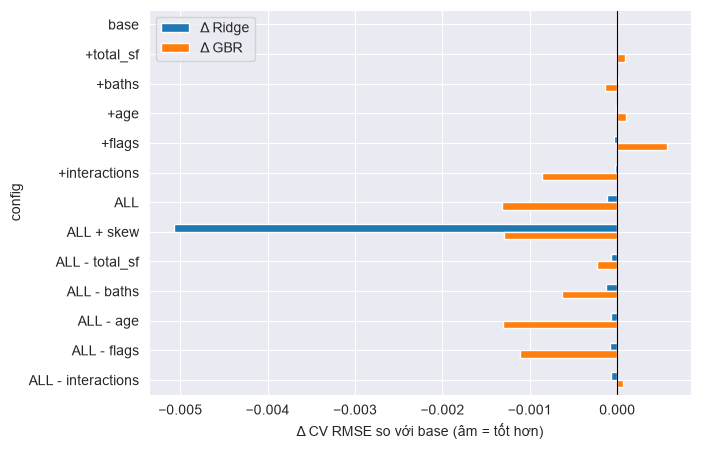

In [10]:
abl.set_index('config')[['Δ Ridge', 'Δ GBR']].plot.barh(figsize=(7, 5))
plt.axvline(0, color='k', lw=.8); plt.xlabel('Δ CV RMSE so với base (âm = tốt hơn)')
plt.gca().invert_yaxis(); plt.show()

In [11]:
x_tr, _ = build([])
r = []
for s in range(5):
    m = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=s)
    r.append(evaluate(m, x_tr, y_train)[0].mean())
print('GBR base, 5 seed:', np.round(r, 5), '| độ lệch chuẩn =', round(float(np.std(r)), 5))

GBR base, 5 seed: [0.11863 0.11754 0.11739 0.11831 0.11755] | độ lệch chuẩn = 0.00049


## 2.5. Lưu

In [12]:
USE, SKEW = ['total_sf', 'baths', 'interactions'], True   # <- sửa theo kết quả ablation của bạn
x_train, x_test = build(USE, SKEW)
y_train = np.log1p(df_clean.loc[df_clean.is_train == 1, 'SalePrice'].values)
test_id = df_clean.loc[df_clean.is_train == 0, 'Id'].values
assert len(x_train) == len(y_train), (len(x_train), len(y_train))
save_feature_set(FEATURE_SET, x_train, y_train, x_test, test_id,
                 info={'notebook': NOTEBOOK, 'member': MEMBER, 'groups': USE, 'skew': SKEW})

[save] d:/HocSau/House_Prices/house_prices_project/exps/feature4: x_train (1456, 293), x_test (1459, 293)


### Kết luận
- Giảm skew giúp Ridge rõ nhất (0.1262 → 0.1211). Đặc trưng tương tác chất lượng × diện tích là nhóm đóng góp thật cho GBR (bỏ đi làm GBR tệ thêm 0.0014, ≈ 3 lần mức dao động 0.0005); các nhóm khác thay đổi trong vùng nhiễu.